# O(n log2 n)

## 1. Import các thư viện

In [24]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os
from utils import plot_execution_times, measure_algorithm_time
import random
import sys

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Cài đặt thuật toán có độ phức tạp O(n log n)

Trong nhóm độ phức tạp O(n log n), có 3 thuật toán phổ biến nhất là **Merge Sort**, **Quick Sort** và **Heap Sort**. Nhóm đã quyết định chọn **Merge Sort** làm thuật toán đại diện chính, đồng thời **tiến hành cài đặt và test thêm Quick Sort** để có cái nhìn đối chiếu toàn diện nhất, dựa trên các lý do sau:

* **Tính ổn định tuyệt đối của Merge Sort trên mọi loại dữ liệu:** Đề bài yêu cầu kiểm thử trên 4 loại phân bố dữ liệu khác nhau. Merge Sort sử dụng cơ chế chia để trị vô điều kiện, luôn đảm bảo thời gian chạy là O(n log n) trong mọi trường hợp (tốt nhất, trung bình, hay xấu nhất). Điều này giúp đường biểu diễn của cả 4 tập dữ liệu bám sát nhau trên đồ thị Log-Log, phản ánh chuẩn xác nhất bản chất lý thuyết của nhóm thuật toán này.

* **Kiểm chứng rủi ro suy biến qua thực nghiệm với Quick Sort:** Nhóm đã test thêm Quick Sort để đối chiếu tốc độ thực tế. Mặc dù Quick Sort thường có hằng số thời gian nhỏ hơn và chạy nhanh hơn ở điều kiện lý tưởng, nhưng thực nghiệm cho thấy nó đối mặt với nguy cơ suy biến (degrade) về O(n^2) hoặc chạm giới hạn đệ quy sâu khi xử lý các mảng đặc thù như **nhiều khóa trùng nhau**, **gần như đã sắp** hoặc **sắp ngược**. Việc test song song cả hai thuật toán giúp nhóm trực quan hóa rõ ràng sự đánh đổi giữa "tốc độ thực tế" (Quick Sort) và "tính ổn định vững vàng" (Merge Sort).

* **So sánh với Heap Sort:** Dù Heap Sort cũng đảm bảo hiệu suất O(n log n) và tối ưu về bộ nhớ (in-place) hơn Merge Sort, nhưng Merge Sort và Quick Sort mang lại sự đối lập thú vị và rõ nét nhất để phân tích, do đó nhóm quyết định tập trung vào hai đại diện này cho bài báo cáo.

### 2.1 Merge sort

In [25]:
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        L = arr[:mid]
        R = arr[mid:]

        merge_sort(L)
        merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1

        while i < len(L):
            arr[k] = L[i]
            i += 1
            k += 1

        while j < len(R):
            arr[k] = R[j]
            j += 1
            k += 1

### 2.2 Quick sort (Bonus)

In [26]:
sys.setrecursionlimit(150000)

def quick_sort(arr):
    def _quick_sort(items, low, high):
        if low < high:
            # Chọn pivot ngẫu nhiên và đưa nó về cuối mảng
            pivot_idx = random.randint(low, high)
            items[high], items[pivot_idx] = items[pivot_idx], items[high]
            
            # Phân hoạch (Partition)
            pi = partition(items, low, high)
            
            # Gọi đệ quy cho 2 nửa
            _quick_sort(items, low, pi - 1)
            _quick_sort(items, pi + 1, high)

    def partition(items, low, high):
        pivot = items[high]
        i = low - 1
        for j in range(low, high):
            if items[j] <= pivot:
                i += 1
                items[i], items[j] = items[j], items[i]
        
        # Đưa pivot vào đúng vị trí
        items[i + 1], items[high] = items[high], items[i + 1]
        return i + 1

    # Bắt đầu gọi hàm đệ quy ẩn bên trong
    _quick_sort(arr, 0, len(arr) - 1)

## 3. Đọc dữ liệu từ file npz

In [27]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

### 4.2 Đo với thuật toán Merge sort

In [28]:
print("Đang đo Merge Sort...")
results_n_logn = measure_algorithm_time(merge_sort, loaded_data, datasets, sizes)

Đang đo Merge Sort...


### 4.2 Đo với thuật toán Quick sort

In [29]:
print("Đang đo Quick Sort")
results_n_logn_bonus = measure_algorithm_time(quick_sort, loaded_data, datasets, sizes)

Đang đo Quick Sort


## 5. Biểu đồ trực quan

### 5.1 Merge sort

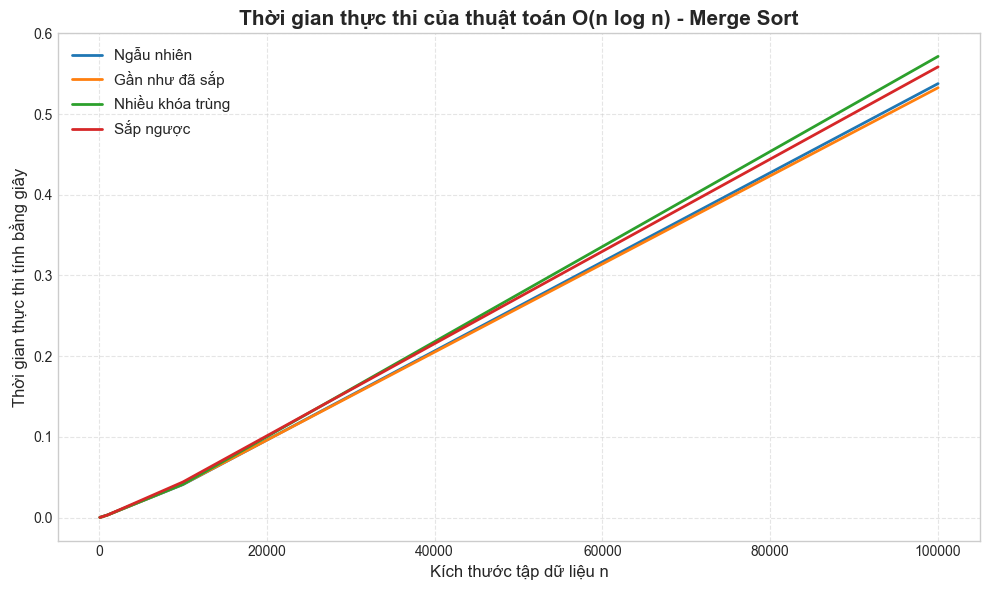

In [30]:
plot_execution_times(
    results_dict=results_n_logn, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Merge Sort"
)

### 5.2 Quick sort

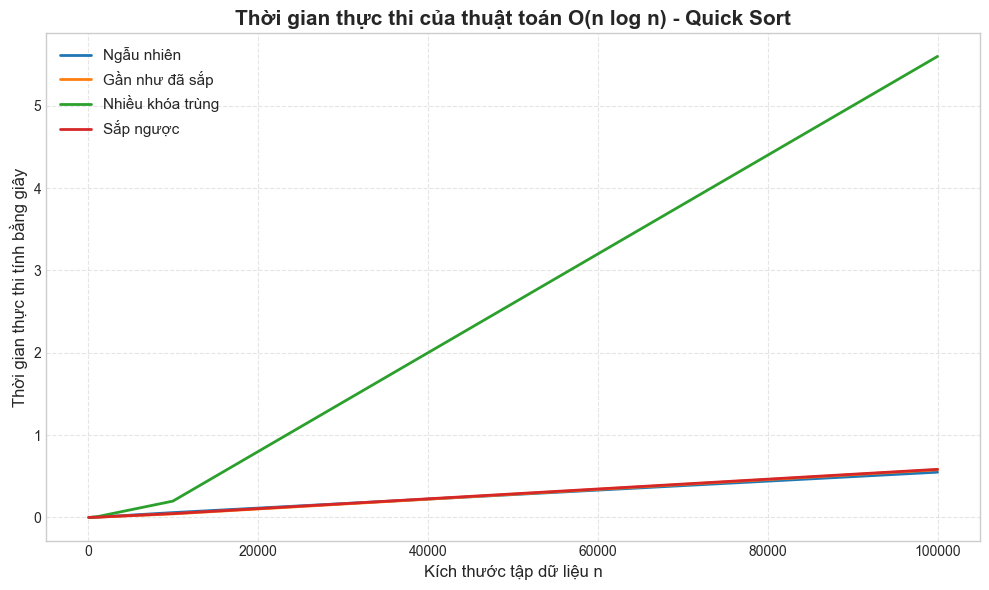

In [31]:
plot_execution_times(
    results_dict=results_n_logn_bonus, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Quick Sort"
)